# DATA 612 Final Project: Hybrid Movie Recommendation System  
## Aaliyah John-Harry

## Project Overview

For this final project, I built a hybrid movie recommender system using the **MovieLens 1M** dataset, Spark ALS collaborative filtering, TMDb metadata, TF-IDF content features, and visual embeddings extracted from movie posters with a pre-trained ResNet50 model.


The system combines three recommendation signals:

1. **Collaborative filtering** using Spark ALS on user-movie ratings.  
2. **Content-based filtering** using movie genres and TMDb metadata.  
3. **Poster image analysis** using visual embeddings extracted from movie posters.

The final hybrid recommender combines collaborative filtering scores with content similarity scores to produce personalized recommendations.


## Setup and Imports

In [1]:
import os
import re
import time
import json
import math
import getpass
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable, total=None, desc=None):
        return iterable

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


## Data Paths


In [2]:
# Project paths
DATA_DIR = Path("data")

ML1M_DIR = DATA_DIR / "ml-1m"
ML_LATEST_SMALL_DIR = DATA_DIR / "ml-latest-small"
TMDB_DIR = DATA_DIR / "tmdb"
POSTER_DIR = DATA_DIR / "posters"

RATINGS_PATH = ML1M_DIR / "ratings.dat"
MOVIES_PATH = ML1M_DIR / "movies.dat"
USERS_PATH = ML1M_DIR / "users.dat"

# MovieLens Latest Small is used only to obtain imdbId/tmdbId mappings.
LATEST_MOVIES_PATH = ML_LATEST_SMALL_DIR / "movies.csv"
LINKS_PATH = ML_LATEST_SMALL_DIR / "links.csv"

TMDB_MOVIES_PATH = TMDB_DIR / "tmdb_metadata.csv"
MATCHED_LINKS_PATH = TMDB_DIR / "movielens_1m_tmdb_links.csv"
POSTER_EMBEDDINGS_PATH = TMDB_DIR / "poster_embeddings.npy"
POSTER_EMBEDDINGS_INDEX_PATH = TMDB_DIR / "poster_embeddings_movie_ids.csv"

for folder in [DATA_DIR, ML1M_DIR, ML_LATEST_SMALL_DIR, TMDB_DIR, POSTER_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

for path in [
    RATINGS_PATH,
    MOVIES_PATH,
    USERS_PATH,
    LATEST_MOVIES_PATH,
    LINKS_PATH
]:
    print(f"{path}: {path.exists()}")


data/ml-1m/ratings.dat: True
data/ml-1m/movies.dat: True
data/ml-1m/users.dat: True
data/ml-latest-small/movies.csv: True
data/ml-latest-small/links.csv: True


## Load MovieLens 1M Data

In [3]:
def check_required_files():
    required = [RATINGS_PATH, MOVIES_PATH, USERS_PATH]
    missing = [path for path in required if not path.exists()]

    if missing:
        print("Missing required MovieLens 1M files:")
        for path in missing:
            print(" -", path)
        print(
            "Download MovieLens 1M, unzip it, and place ratings.dat, "
            "movies.dat, and users.dat inside data/ml-1m/."
        )
        return False

    print("All required MovieLens 1M files were found.")
    return True

FILES_READY = check_required_files()


All required MovieLens 1M files were found.


In [4]:
ratings = pd.read_csv(
    RATINGS_PATH,
    sep="::",
    engine="python",
    names=["userId", "movieId", "rating", "timestamp"],
    encoding="latin-1"
)

movies = pd.read_csv(
    MOVIES_PATH,
    sep="::",
    engine="python",
    names=["movieId", "title", "genres"],
    encoding="latin-1"
)

users = pd.read_csv(
    USERS_PATH,
    sep="::",
    engine="python",
    names=["userId", "gender", "age", "occupation", "zip"],
    encoding="latin-1"
)

ratings.head(), movies.head(), users.head()


(   userId  movieId  rating  timestamp
 0       1     1193       5  978300760
 1       1      661       3  978302109
 2       1      914       3  978301968
 3       1     3408       4  978300275
 4       1     2355       5  978824291,
    movieId                               title                        genres
 0        1                    Toy Story (1995)   Animation|Children's|Comedy
 1        2                      Jumanji (1995)  Adventure|Children's|Fantasy
 2        3             Grumpier Old Men (1995)                Comedy|Romance
 3        4            Waiting to Exhale (1995)                  Comedy|Drama
 4        5  Father of the Bride Part II (1995)                        Comedy,
    userId gender  age  occupation    zip
 0       1      F    1          10  48067
 1       2      M   56          16  70072
 2       3      M   25          15  55117
 3       4      M   45           7  02460
 4       5      M   25          20  55455)

## Data Exploration

- The MovieLens 1M dataset contains just over 1 million ratings from 6,040 users across 3,706 movies, making it a good size for evaluating recommendation algorithms.
- The average rating is 3.58, and the rating distribution shows that users tend to give more positive ratings, with 3 and 4-star ratings being the most common.
- The dataset is very sparse (95.5%), meaning each user has rated only a small fraction of the available movies. 
    - This sparsity is a common challenge in recommender systems and is one of the reasons collaborative filtering methods are valuable.
- The distributions of ratings per movie and ratings per user are both heavily right-skewed. 
    - Most movies receive relatively few ratings, while a small number of popular movies receive thousands of ratings. 
    - Likewise, most users rate only a limited number of movies, while a small group of highly active users contribute many ratings.
- Looking at the highest-rated movies (restricted to those with at least 100 ratings) shows well-known classics like The Shawshank Redemption, Raiders of the Lost Ark and The Godfather near the top of the list. 
    - This is a useful sanity check that proves that the dataset is behaving as expected before building the recommendation models.

In [5]:
print("Ratings shape:", ratings.shape)
print("Movies shape:", movies.shape)
print("Users shape:", users.shape)

summary = pd.DataFrame({
    "Metric": ["Number of ratings", "Number of users", "Number of movies", "Average rating", "Rating sparsity"],
    "Value": [
        len(ratings),
        ratings["userId"].nunique(),
        ratings["movieId"].nunique(),
        round(ratings["rating"].mean(), 3),
        round(1 - len(ratings) / (ratings["userId"].nunique() * ratings["movieId"].nunique()), 4)
    ]
})
summary


Ratings shape: (1000209, 4)
Movies shape: (3883, 3)
Users shape: (6040, 5)


,Metric,Value
0,Number of ratings,1.000209e+06
1,Number of users,6.040000e+03
2,Number of movies,3.706000e+03
3,Average rating,3.582000e+00
4,Rating sparsity,9.553000e-01


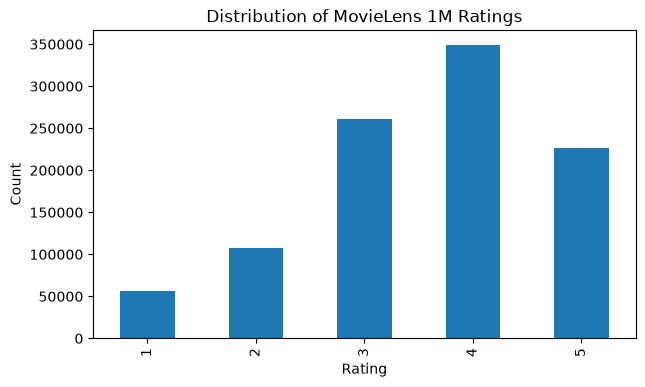

In [6]:
plt.figure(figsize=(7,4))
ratings["rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of MovieLens 1M Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()


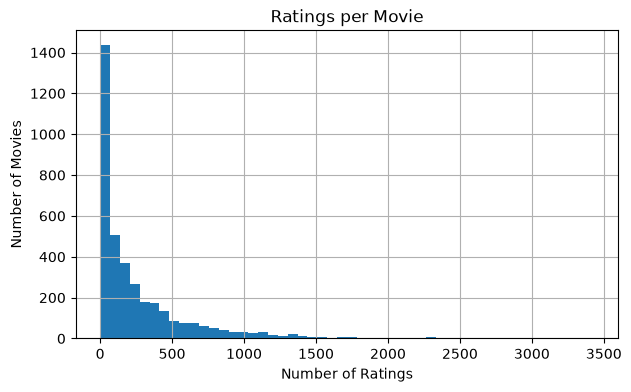

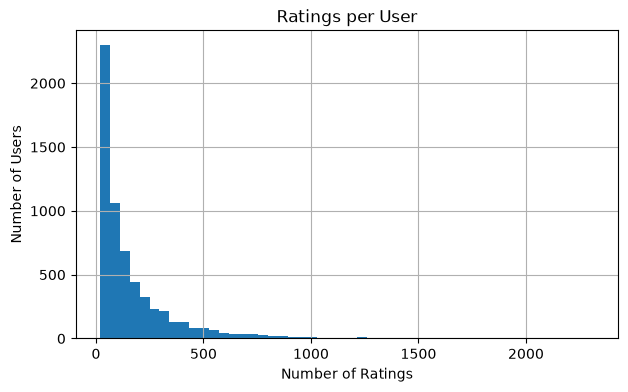

In [7]:
ratings_per_movie = ratings.groupby("movieId").size().rename("rating_count")
ratings_per_user = ratings.groupby("userId").size().rename("rating_count")

fig = plt.figure(figsize=(7,4))
ratings_per_movie.hist(bins=50)
plt.title("Ratings per Movie")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Movies")
plt.show()

fig = plt.figure(figsize=(7,4))
ratings_per_user.hist(bins=50)
plt.title("Ratings per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")
plt.show()


In [8]:
top_movies = (
    ratings.merge(movies, on="movieId")
    .groupby(["movieId", "title"])
    .agg(avg_rating=("rating", "mean"), rating_count=("rating", "size"))
    .reset_index()
    .query("rating_count >= 100")
    .sort_values(["avg_rating", "rating_count"], ascending=False)
    .head(10)
)
top_movies


,movieId,title,avg_rating,rating_count
1839,2019,Seven Samurai (The Magnificent Seven) (Shichin...,4.560510,628
309,318,"Shawshank Redemption, The (1994)",4.554558,2227
802,858,"Godfather, The (1972)",4.524966,2223
708,745,"Close Shave, A (1995)",4.520548,657
49,50,"Usual Suspects, The (1995)",4.517106,1783
513,527,Schindler's List (1993),4.510417,2304
1066,1148,"Wrong Trousers, The (1993)",4.507937,882
861,922,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),4.491489,470
1108,1198,Raiders of the Lost Ark (1981),4.477725,2514
843,904,Rear Window (1954),4.476190,1050


## Prepare Movie Metadata

I prepared the movie metadata that would be used by the content-based component of the hybrid recommender. 
- I extracted the release year from each MovieLens title, cleaned and standardized the movie titles, and converted the pipe-separated genres into a single text feature.
- I also reformatted titles such as "Matrix, The" to "The Matrix" and removed punctuation and other formatting inconsistencies. 
    - This helped to improve matching with the external TMDb metadata that I incorporated later in the project.

In [9]:
def extract_year(title):
    match = re.search(r"\((\d{4})\)\s*$", str(title))
    return int(match.group(1)) if match else np.nan


def clean_title(title):
    title = str(title)
    title = re.sub(r"\s*\(\d{4}\)\s*$", "", title)

    # Convert MovieLens titles such as "Matrix, The" to "The Matrix".
    article_match = re.match(r"^(.*),\s+(The|A|An)$", title, flags=re.IGNORECASE)
    if article_match:
        title = f"{article_match.group(2)} {article_match.group(1)}"

    title = title.lower().replace("&", "and")
    title = re.sub(r"[^a-z0-9]+", " ", title)
    return re.sub(r"\s+", " ", title).strip()


movies["year"] = movies["title"].apply(extract_year)
movies["clean_title"] = movies["title"].apply(clean_title)
movies["genre_text"] = movies["genres"].fillna("").str.replace("|", " ", regex=False)

movies.head()


,movieId,title,genres,year,clean_title,genre_text
0,1,Toy Story (1995),Animation|Children's|Comedy,1995,toy story,Animation Children's Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy,1995,jumanji,Adventure Children's Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance,1995,grumpier old men,Comedy Romance
3,4,Waiting to Exhale (1995),Comedy|Drama,1995,waiting to exhale,Comedy Drama
4,5,Father of the Bride Part II (1995),Comedy,1995,father of the bride part ii,Comedy


## Match MovieLens 1M Movies to TMDb IDs

Since the MovieLens 1M dataset doesn't include TMDb identifiers, I created a mapping between MovieLens 1M and the MovieLens Latest Small dataset (which already contains links.csv with TMDb IDs).

- To improve the matching process, I used the cleaned movie titles and release years.
    - This allowed me to match movies even though the two MovieLens datasets use different internal movie IDs.
- Using this approach, I successfully matched 2,684 of the 3,883 movies (69.1%) to a TMDb ID and saved the results as a reusable mapping file for the rest of the project.
- About 1,199 movies could not be matched, which is expected because some titles differ between the two datasets or are not included in the MovieLens Latest Small dataset. 
- Nevertheless, the matched movies represented most of the ratings in the dataset and provided enough coverage to enhance the recommender with additional TMDb metadata and poster images.

In [10]:
if not LATEST_MOVIES_PATH.exists() or not LINKS_PATH.exists():
    raise FileNotFoundError(
        "MovieLens Latest Small mapping files were not found. "
        "Place movies.csv and links.csv inside data/ml-latest-small/."
    )

latest_movies = pd.read_csv(LATEST_MOVIES_PATH)
links = pd.read_csv(LINKS_PATH)

latest_movies["year"] = latest_movies["title"].apply(extract_year)
latest_movies["clean_title"] = latest_movies["title"].apply(clean_title)

latest_with_links = latest_movies.merge(links, on="movieId", how="left")
latest_with_links = latest_with_links.rename(
    columns={"movieId": "latestMovieId", "title": "latest_title"}
)

movies_with_links = movies.merge(
    latest_with_links[
        ["latestMovieId", "latest_title", "clean_title", "year", "imdbId", "tmdbId"]
    ],
    on=["clean_title", "year"],
    how="left"
)

movies_with_links = (
    movies_with_links
    .sort_values(["movieId", "tmdbId"], na_position="last")
    .drop_duplicates(subset=["movieId"], keep="first")
    .reset_index(drop=True)
)

matched_count = movies_with_links["tmdbId"].notna().sum()
print(f"Matched movies: {matched_count:,} of {len(movies_with_links):,}")
print(f"Match rate: {matched_count / len(movies_with_links):.1%}")

movies_with_links.to_csv(MATCHED_LINKS_PATH, index=False)
print("Saved mapping to:", MATCHED_LINKS_PATH)

movies_with_links[
    ["movieId", "title", "latest_title", "tmdbId"]
].head(10)


Matched movies: 2,684 of 3,883
Match rate: 69.1%
Saved mapping to: data/tmdb/movielens_1m_tmdb_links.csv


,movieId,title,latest_title,tmdbId
0,1,Toy Story (1995),Toy Story (1995),862.0
1,2,Jumanji (1995),Jumanji (1995),8844.0
2,3,Grumpier Old Men (1995),Grumpier Old Men (1995),15602.0
3,4,Waiting to Exhale (1995),Waiting to Exhale (1995),31357.0
4,5,Father of the Bride Part II (1995),Father of the Bride Part II (1995),11862.0
5,6,Heat (1995),Heat (1995),949.0
6,7,Sabrina (1995),Sabrina (1995),11860.0
7,8,Tom and Huck (1995),Tom and Huck (1995),45325.0
8,9,Sudden Death (1995),Sudden Death (1995),9091.0
9,10,GoldenEye (1995),GoldenEye (1995),710.0


In [11]:
unmatched_movies = movies_with_links.loc[
    movies_with_links["tmdbId"].isna(),
    ["movieId", "title", "year"]
].copy()

print("Unmatched movies:", len(unmatched_movies))
unmatched_movies.head(20)


Unmatched movies: 1199


,movieId,title,year
28,29,"City of Lost Children, The (1995)",1995
31,32,Twelve Monkeys (1995),1995
32,33,Wings of Courage (1995),1995
34,35,Carrington (1995),1995
36,37,Across the Sea of Time (1995),1995
46,47,Seven (Se7en) (1995),1995
50,51,Guardian Angel (1994),1994
55,56,Kids of the Round Table (1995),1995
57,58,"Postino, Il (The Postman) (1994)",1994
58,59,"Confessional, The (Le Confessionnal) (1995)",1995


## Collect TMDb Metadata and Download Posters

- After matching the movies to TMDb IDs, I used the TMDb API to collect additional metadata for each matched movie, like the overview, genres, runtime, popularity, vote average, release date, and other descriptive features.
- I also downloaded each movie's poster image, which I will use later to extract visual features for the hybrid recommender. 
    - These poster embeddings will provide another source of information beyond ratings and genre metadata by capturing visual similarities between movies.
- To make the data collection process more reliable, I included automatic retries for failed requests and saved the metadata locally so the notebook could resume from previous runs instead of downloading everything again.
- In total, I successfully collected metadata and poster images for 2,684 movies, creating a richer dataset by combining collaborative filtering data with both textual and visual movie information.

In [12]:
# Enter your TMDb v3 API key securely.
TMDB_API_KEY = getpass.getpass("Enter your TMDb API Key (v3 auth): ").strip()

if not TMDB_API_KEY:
    raise ValueError("A TMDb API key is required to collect metadata and posters.")

# Start with 100 for testing. Change to None for all matched movies.
MAX_MOVIES = None
DOWNLOAD_POSTERS = True


In [13]:
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

retry_strategy = Retry(
    total=5,
    backoff_factor=1,
    status_forcelist=[429, 500, 502, 503, 504],
    allowed_methods=["GET"]
)

session = requests.Session()
adapter = HTTPAdapter(max_retries=retry_strategy)
session.mount("https://", adapter)
session.mount("http://", adapter)

test_response = session.get(
    "https://api.themoviedb.org/3/movie/862",
    params={"api_key": TMDB_API_KEY, "language": "en-US"},
    timeout=30
)

print("TMDb test status:", test_response.status_code)
if test_response.status_code == 200:
    print("Connected successfully. Test movie:", test_response.json().get("title"))
else:
    raise RuntimeError(
        f"TMDb authentication failed: {test_response.status_code} {test_response.text}"
    )


TMDb test status: 200
Connected successfully. Test movie: Toy Story


In [14]:
TMDB_IMAGE_BASE_URL = "https://image.tmdb.org/t/p"
POSTER_SIZE = "w500"


def get_tmdb_movie_details(tmdb_id):
    if pd.isna(tmdb_id):
        return None

    url = f"https://api.themoviedb.org/3/movie/{int(tmdb_id)}"
    params = {"api_key": TMDB_API_KEY, "language": "en-US"}

    try:
        response = session.get(url, params=params, timeout=30)

        if response.status_code == 200:
            return response.json()
        if response.status_code == 404:
            return None

        print(f"TMDb request failed for {tmdb_id}: {response.status_code}")
    except requests.RequestException as exc:
        print(f"Request error for TMDb ID {tmdb_id}: {exc}")

    return None


def download_poster(movie_id, poster_path):
    if not poster_path:
        return False

    output_path = POSTER_DIR / f"{int(movie_id)}.jpg"

    if output_path.exists() and output_path.stat().st_size > 0:
        return True

    poster_url = f"{TMDB_IMAGE_BASE_URL}/{POSTER_SIZE}{poster_path}"

    try:
        response = session.get(poster_url, timeout=30)
        content_type = response.headers.get("Content-Type", "")

        if response.status_code == 200 and content_type.startswith("image/"):
            output_path.write_bytes(response.content)
            return True
    except requests.RequestException as exc:
        print(f"Poster error for movie {movie_id}: {exc}")

    return False


In [15]:
eligible_movies = movies_with_links.dropna(subset=["tmdbId"]).copy()
eligible_movies["tmdbId"] = eligible_movies["tmdbId"].astype(int)

# Resume from an existing metadata file.
if TMDB_MOVIES_PATH.exists():
    existing_tmdb = pd.read_csv(TMDB_MOVIES_PATH)
    completed_ids = set(
        existing_tmdb.loc[
            existing_tmdb["tmdb_request_success"].fillna(False).astype(bool),
            "movieId"
        ].astype(int)
    )
else:
    existing_tmdb = pd.DataFrame()
    completed_ids = set()

remaining_movies = eligible_movies[
    ~eligible_movies["movieId"].astype(int).isin(completed_ids)
].copy()

if MAX_MOVIES is not None:
    remaining_movies = remaining_movies.head(MAX_MOVIES)

print("Previously completed:", len(completed_ids))
print("Movies in this run:", len(remaining_movies))


Previously completed: 2684
Movies in this run: 0


In [16]:
metadata_rows = []

for row in tqdm(
    remaining_movies.itertuples(index=False),
    total=len(remaining_movies),
    desc="Collecting TMDb metadata"
):
    details = get_tmdb_movie_details(row.tmdbId)

    if details is None:
        metadata_rows.append({
            "movieId": row.movieId,
            "tmdbId": row.tmdbId,
            "tmdb_request_success": False,
            "poster_downloaded": False
        })
        continue

    genres = "|".join(
        item.get("name", "")
        for item in details.get("genres", [])
        if item.get("name")
    )
    production_companies = "|".join(
        item.get("name", "")
        for item in details.get("production_companies", [])
        if item.get("name")
    )

    poster_path = details.get("poster_path")
    poster_downloaded = (
        download_poster(row.movieId, poster_path)
        if DOWNLOAD_POSTERS
        else False
    )

    metadata_rows.append({
        "movieId": row.movieId,
        "tmdbId": row.tmdbId,
        "imdb_id": details.get("imdb_id"),
        "tmdb_title": details.get("title"),
        "original_title": details.get("original_title"),
        "overview": details.get("overview"),
        "tagline": details.get("tagline"),
        "release_date": details.get("release_date"),
        "runtime": details.get("runtime"),
        "tmdb_genres": genres,
        "popularity": details.get("popularity"),
        "vote_average": details.get("vote_average"),
        "vote_count": details.get("vote_count"),
        "original_language": details.get("original_language"),
        "budget": details.get("budget"),
        "revenue": details.get("revenue"),
        "status": details.get("status"),
        "production_companies": production_companies,
        "poster_path": poster_path,
        "backdrop_path": details.get("backdrop_path"),
        "homepage": details.get("homepage"),
        "tmdb_request_success": True,
        "poster_downloaded": poster_downloaded
    })

    time.sleep(0.05)

new_tmdb = pd.DataFrame(metadata_rows)

tmdb_metadata = pd.concat(
    [existing_tmdb, new_tmdb],
    ignore_index=True,
    sort=False
)

if not tmdb_metadata.empty:
    tmdb_metadata = (
        tmdb_metadata
        .sort_values("movieId")
        .drop_duplicates(subset=["movieId"], keep="last")
        .reset_index(drop=True)
    )
    tmdb_metadata.to_csv(TMDB_MOVIES_PATH, index=False)

print("Saved TMDb metadata to:", TMDB_MOVIES_PATH)
print("Metadata rows:", len(tmdb_metadata))
print("Poster files:", len(list(POSTER_DIR.glob("*.jpg"))))

tmdb_metadata.head()


Saved TMDb metadata to: data/tmdb/tmdb_metadata.csv
Metadata rows: 2684
Poster files: 2684


,movieId,tmdbId,imdb_id,tmdb_title,original_title,overview,tagline,release_date,runtime,tmdb_genres,popularity,vote_average,vote_count,original_language,budget,revenue,status,production_companies,poster_path,backdrop_path,homepage,tmdb_request_success,poster_downloaded
0,1,862,tt0114709,Toy Story,Toy Story,"Led by Woody, Andy's toys live happily in his ...",The adventure takes off when toys come to life!,1995-11-22,81,Family|Comedy|Animation|Adventure,55.5705,8.000,20139,en,30000000,401157969,Released,Pixar,/uXDfjJbdP4ijW5hWSBrPrlKpxab.jpg,/3Rfvhy1Nl6sSGJwyjb0QiZzZYlB.jpg,http://toystory.disney.com/toy-story,True,True
1,2,8844,tt0113497,Jumanji,Jumanji,When siblings Judy and Peter discover an encha...,It's a jungle in here.,1995-12-15,104,Adventure|Fantasy|Family,3.2113,7.249,11381,en,65000000,262821940,Released,TriStar Pictures|Interscope Communications|Tei...,/iWV47r6kFneCiApgrMII5HSkfHw.jpg,/qSxeCfWUUyht9hZgaaYmtPtTkw2.jpg,http://www.sonypictures.com/movies/jumanji/,True,True
2,3,15602,tt0113228,Grumpier Old Men,Grumpier Old Men,A family wedding reignites the ancient feud be...,Still Yelling. Still Fighting. Still Ready for...,1995-12-22,101,Romance|Comedy,2.7880,6.479,432,en,25000000,71518503,Released,Lancaster Gate|Warner Bros. Pictures,/1FSXpj5e8l4KH6nVFO5SPUeraOt.jpg,/1o4vuCHpmd4DXofMYDUwpnhKiuy.jpg,NaN,True,True
3,4,31357,tt0114885,Waiting to Exhale,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",Friends are the people who let you be yourself...,1995-12-22,127,Comedy|Drama|Romance,3.4319,6.261,207,en,16000000,81452156,Released,20th Century Fox,/4wjGMwPsdlvi025ZqR4rXnFDvBz.jpg,/jZjoEKXMTDoZAGdkjhAdJaKtXSN.jpg,NaN,True,True
4,5,11862,tt0113041,Father of the Bride Part II,Father of the Bride Part II,Just when George Banks has recovered from his ...,Just when his world is back to normal... he's ...,1995-12-08,106,Comedy|Family,2.2891,6.271,814,en,0,76594107,Released,Touchstone Pictures|Sandollar Productions,/rj4LBtwQ0uGrpBnCELr716Qo3mw.jpg,/lEsjVrGU21BeJjF5AF9EWsihDpw.jpg,NaN,True,True


## Merge TMDb Metadata with MovieLens
In this section, I merged the TMDb metadata collected in the previous step with the original MovieLens dataset using the matched movie IDs.
- I combined the original MovieLens genres with the TMDb genres, movie overviews, and taglines to create a richer text representation for each movie. 
    - Later in the project, I vectorized these combined text features so that they can be used by the content-based recommender.
- I kept all MovieLens movies in the dataset, even if they could not be matched to TMDb so I can preserve the full recommendation catalog while allowing the matched movies to benefit from the additional TMDb metadata.

In [17]:
if not TMDB_MOVIES_PATH.exists():
    raise FileNotFoundError(
        f"TMDb metadata was not found at {TMDB_MOVIES_PATH}. "
        "Run the TMDb collection cells first."
    )

tmdb = pd.read_csv(TMDB_MOVIES_PATH)
print("TMDb metadata found:", tmdb.shape)

movies_enriched = movies.merge(
    tmdb,
    on="movieId",
    how="left",
    suffixes=("", "_tmdb")
)

for column in ["overview", "tagline", "tmdb_genres"]:
    if column not in movies_enriched.columns:
        movies_enriched[column] = ""
    movies_enriched[column] = movies_enriched[column].fillna("").astype(str)

movies_enriched["tmdb_genre_text"] = (
    movies_enriched["tmdb_genres"].str.replace("|", " ", regex=False)
)

movies_enriched["content_text"] = (
    movies_enriched["genre_text"]
    + " "
    + movies_enriched["tmdb_genre_text"]
    + " "
    + movies_enriched["tagline"]
    + " "
    + movies_enriched["overview"]
).str.replace(r"\s+", " ", regex=True).str.strip()

metadata_coverage = movies_enriched["tmdbId"].notna().mean()
overview_coverage = movies_enriched["overview"].str.strip().ne("").mean()
poster_coverage = (
    movies_enriched["poster_downloaded"].fillna(False).astype(bool).mean()
    if "poster_downloaded" in movies_enriched.columns
    else 0
)

print(f"TMDb metadata coverage: {metadata_coverage:.1%}")
print(f"Overview coverage: {overview_coverage:.1%}")
print(f"Poster coverage: {poster_coverage:.1%}")

movies_enriched[
    [
        "movieId", "title", "genres", "tmdb_title", "overview",
        "runtime", "popularity", "vote_average", "poster_downloaded"
    ]
].head()


TMDb metadata found: (2684, 23)
TMDb metadata coverage: 69.1%
Overview coverage: 69.1%
Poster coverage: 69.1%


,movieId,title,genres,tmdb_title,overview,runtime,popularity,vote_average,poster_downloaded
0,1,Toy Story (1995),Animation|Children's|Comedy,Toy Story,"Led by Woody, Andy's toys live happily in his ...",81.0,55.5705,8.000,True
1,2,Jumanji (1995),Adventure|Children's|Fantasy,Jumanji,When siblings Judy and Peter discover an encha...,104.0,3.2113,7.249,True
2,3,Grumpier Old Men (1995),Comedy|Romance,Grumpier Old Men,A family wedding reignites the ancient feud be...,101.0,2.7880,6.479,True
3,4,Waiting to Exhale (1995),Comedy|Drama,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",127.0,3.4319,6.261,True
4,5,Father of the Bride Part II (1995),Comedy,Father of the Bride Part II,Just when George Banks has recovered from his ...,106.0,2.2891,6.271,True


## Poster Image Analysis with ResNet50

Rather than training a CNN from scratch, I used a pretrained ResNet50 model as a feature extractor. This allowed visually similar posters to be represented by numerical embedding vectors without requiring manually labeled movie images.

- I resized and preprocessed each poster before passing it through the model, then removed the final classification layer so ResNet50 could be used as a feature extractor instead of an image classifier.
- Each poster was represented as a 2,048-dimensional embedding, which captures visual patterns such as color, layout, texture, and overall design style.
- I created embeddings for all 2,684 downloaded posters and saved them locally so they could be reused without processing the images again.

These visual features give the content-based recommender another source of information beyond genres and text, helping it identify movies with similar poster styles or visual themes.


In [18]:
RUN_POSTER_ANALYSIS = True

if RUN_POSTER_ANALYSIS:
    from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
    from tensorflow.keras.preprocessing import image

    poster_files = sorted(POSTER_DIR.glob("*.jpg"))
    if not poster_files:
        raise FileNotFoundError(
            f"No poster images were found in {POSTER_DIR}. "
            "Run the TMDb download cells first."
        )

    base_model = ResNet50(
        weights="imagenet",
        include_top=False,
        pooling="avg"
    )

    movie_ids = []
    embeddings = []

    for poster_file in tqdm(poster_files, desc="Extracting poster embeddings"):
        try:
            movie_id = int(poster_file.stem)
            img = image.load_img(poster_file, target_size=(224, 224))
            x = image.img_to_array(img)
            x = np.expand_dims(x, axis=0)
            x = preprocess_input(x)

            embedding = base_model.predict(x, verbose=0).flatten()
            movie_ids.append(movie_id)
            embeddings.append(embedding)
        except Exception as exc:
            print(f"Skipped {poster_file.name}: {exc}")

    if embeddings:
        embeddings = np.vstack(embeddings)
        np.save(POSTER_EMBEDDINGS_PATH, embeddings)
        pd.DataFrame({"movieId": movie_ids}).to_csv(
            POSTER_EMBEDDINGS_INDEX_PATH,
            index=False
        )
        print("Saved poster embeddings:", embeddings.shape)
    else:
        print("No poster embeddings were created.")
else:
    print(
        "Poster analysis skipped. Set RUN_POSTER_ANALYSIS = True "
        "after downloading poster images."
    )


Extracting poster embeddings:   0%|          | 0/2684 [00:00<?, ?it/s]

Saved poster embeddings: (2684, 2048)


## Start Spark Session


In [19]:
import os
os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"

In [20]:
import os
import sys
import subprocess

os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"

java_home = subprocess.check_output(
    ["/usr/libexec/java_home", "-v", "17"],
    text=True
).strip()

os.environ["JAVA_HOME"] = java_home
os.environ["PATH"] = f"{java_home}/bin:{os.environ['PATH']}"

print("Python:", sys.executable)
print("JAVA_HOME:", os.environ["JAVA_HOME"])

Python: /Users/aaliyahmjh/.venv/bin/python
JAVA_HOME: /opt/homebrew/Cellar/openjdk@17/17.0.19/libexec/openjdk.jdk/Contents/Home


In [21]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator

spark = (
    SparkSession.builder
    .appName("DATA612_Final_Hybrid_Recommender")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")
print(spark.version)


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/14 19:18:31 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


3.5.1


## Spark ALS Collaborative Filtering Model

I trained an ALS collaborative filtering model using Spark on an 80/20 train-test split of the MovieLens 1M ratings. ALS learns latent factors for both users and movies, allowing it to recommend movies based on patterns in user behavior rather than relying on movie content alone.

- After training, the model achieved an RMSE of 0.8714, indicating that it was able to predict user ratings with good accuracy.
- I also generated the top 10 recommendations for every user, which served as the collaborative filtering component of the final hybrid recommender.
- The ALS predictions from this model were later used as the collaborative filtering component of the hybrid recommender.

In [22]:
ratings_spark = spark.createDataFrame(ratings[["userId", "movieId", "rating"]])
ratings_spark = ratings_spark.select(
    col("userId").cast("int"),
    col("movieId").cast("int"),
    col("rating").cast("float")
)

train_spark, test_spark = ratings_spark.randomSplit([0.8, 0.2], seed=RANDOM_SEED)
print("Train count:", train_spark.count())
print("Test count:", test_spark.count())

train_pd = train_spark.toPandas()
test_pd = test_spark.toPandas()

Train count: 800471
Test count: 199738


In [23]:
als = ALS(
    userCol="userId",
    itemCol="movieId",
    ratingCol="rating",
    rank=20,
    maxIter=10,
    regParam=0.1,
    coldStartStrategy="drop",
    nonnegative=True,
    seed=RANDOM_SEED
)

als_model = als.fit(train_spark)
als_predictions = als_model.transform(test_spark)

rmse_evaluator = RegressionEvaluator(
    metricName="rmse",
    labelCol="rating",
    predictionCol="prediction"
)
als_rmse = rmse_evaluator.evaluate(als_predictions)
print(f"ALS RMSE: {als_rmse:.4f}")


ALS RMSE: 0.8714


In [24]:
N = 10
als_recs_spark = als_model.recommendForAllUsers(N)
als_recs_spark.show(3, truncate=False)


+------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|userId|recommendations                                                                                                                                                                     |
+------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|6     |[{572, 5.385893}, {1035, 4.675185}, {3314, 4.658597}, {2562, 4.6491175}, {297, 4.557158}, {3233, 4.5205965}, {920, 4.4880805}, {1871, 4.42651}, {37, 4.4101152}, {831, 4.390006}]   |
|9     |[{572, 4.7926416}, {1851, 4.561836}, {318, 4.4003296}, {2309, 4.378881}, {2905, 4.326639}, {50, 4.320295}, {527, 4.287901}, {989, 4.2712045}, {858, 4.240212}, {2324, 4.2079153}]   |
|12    |[{2309, 4.7309985}, {572, 4.716364}, {557,

## Content-Based Recommender

In this section, I built the content-based recommendation model using both the original MovieLens genres and the additional TMDb metadata that I collected earlier.

- I combined the genres, TMDb genres, taglines, and movie overviews into a single content text field and used TF-IDF vectorization to convert this text into numerical features that describe each movie.
- I also loaded the ResNet50 poster embeddings, allowing the recommender to incorporate visual information in addition to textual metadata.
- To measure similarity between movies, I calculated cosine similarity on the TF-IDF feature matrix and returned the movies with the highest similarity scores.
- Higher content scores indicate that the movie shares more similar genres, themes, and textual metadata, making it a stronger content-based recommendation.
Using Toy Story as an example, the recommender returned movies with similar genres and themes, demonstrating that the content-based approach is able to identify related movies based on their characteristics rather than user ratings.

In [25]:
required_columns = ["movieId", "title", "genres", "year", "content_text"]
missing_columns = [c for c in required_columns if c not in movies_enriched.columns]

if missing_columns:
    raise KeyError(f"Missing content columns: {missing_columns}")

content_df = movies_enriched[required_columns].copy()
content_df["content_text"] = (
    content_df["content_text"]
    .fillna("")
    .astype(str)
    .replace("", "unknown")
)

print("Movies in content model:", len(content_df))
content_df.head()


Movies in content model: 3883


,movieId,title,genres,year,content_text
0,1,Toy Story (1995),Animation|Children's|Comedy,1995,Animation Children's Comedy Family Comedy Anim...
1,2,Jumanji (1995),Adventure|Children's|Fantasy,1995,Adventure Children's Fantasy Adventure Fantasy...
2,3,Grumpier Old Men (1995),Comedy|Romance,1995,Comedy Romance Romance Comedy Still Yelling. S...
3,4,Waiting to Exhale (1995),Comedy|Drama,1995,Comedy Drama Comedy Drama Romance Friends are ...
4,5,Father of the Bride Part II (1995),Comedy,1995,Comedy Comedy Family Just when his world is ba...


In [26]:
tfidf = TfidfVectorizer(stop_words="english", max_features=5000, min_df=1)
tfidf_matrix = tfidf.fit_transform(content_df["content_text"])

movie_id_to_idx = {mid: idx for idx, mid in enumerate(content_df["movieId"])}
idx_to_movie_id = {idx: mid for mid, idx in movie_id_to_idx.items()}

print("TF-IDF matrix shape:", tfidf_matrix.shape)


TF-IDF matrix shape: (3883, 5000)


In [27]:

poster_similarity_available = POSTER_EMBEDDINGS_PATH.exists() and POSTER_EMBEDDINGS_INDEX_PATH.exists()

if poster_similarity_available:
    poster_embeddings = np.load(POSTER_EMBEDDINGS_PATH)
    poster_index = pd.read_csv(POSTER_EMBEDDINGS_INDEX_PATH)
    poster_movie_id_to_idx = {mid: i for i, mid in enumerate(poster_index["movieId"])}
    print("Poster embeddings loaded:", poster_embeddings.shape)
else:
    print("Poster embeddings not available. Using text metadata only for content similarity.")


Poster embeddings loaded: (2684, 2048)


In [28]:
poster_embeddings = poster_embeddings.astype("float32")

poster_norms = np.linalg.norm(
    poster_embeddings,
    axis=1,
    keepdims=True
)

poster_norms[poster_norms == 0] = 1.0

poster_embeddings_normalized = (
    poster_embeddings / poster_norms
)

print(
    "Normalized poster embeddings:",
    poster_embeddings_normalized.shape
)

Normalized poster embeddings: (2684, 2048)


In [29]:
def get_content_recommendations_for_movie(title_query, top_n=10):
    matches = content_df[content_df["title"].str.contains(title_query, case=False, na=False)]
    if matches.empty:
        return pd.DataFrame()
    movie_id = matches.iloc[0]["movieId"]
    idx = movie_id_to_idx[movie_id]
    sims = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()
    top_idx = sims.argsort()[::-1][1:top_n+1]
    recs = content_df.iloc[top_idx][["movieId", "title", "genres"]].copy()
    recs["content_score"] = sims[top_idx]
    return recs

get_content_recommendations_for_movie("Toy Story", top_n=10)


,movieId,title,genres,content_score
3045,3114,Toy Story 2 (1999),Animation|Children's|Comedy,0.521644
3105,3174,Man on the Moon (1999),Comedy|Drama,0.301363
3542,3611,Saludos Amigos (1943),Animation|Children's|Comedy,0.199139
1205,1223,"Grand Day Out, A (1992)",Animation|Comedy,0.195096
3360,3429,Creature Comforts (1990),Animation|Comedy,0.195096
1132,1148,"Wrong Trousers, The (1993)",Animation|Comedy,0.195096
2931,3000,"Princess Mononoke, The (Mononoke Hime) (1997)",Action|Adventure|Animation,0.192060
1972,2041,Condorman (1981),Action|Adventure|Children's|Comedy,0.189272
2016,2085,101 Dalmatians (1961),Animation|Children's,0.183810
241,244,Gumby: The Movie (1995),Animation|Children's,0.183810


## User Profile Content Recommendations

In this section, I extended the content-based recommender to generate personalized recommendations for individual users rather than just finding movies similar to a given title.

- I built a user profile by averaging the TF-IDF features of the movies that each user rated highly in the training data, creating a representation of that user's preferences.
- Afterwards, I compared the user profile to all unseen movies using cosine similarity and recommended the highest-scoring movies that the user had not already rated.
- The example recommendations are heavily weighted toward animation, children's, and family movies, suggesting that the selected user's previous highly rated movies reflected those interests.
- Unlike the previous section, which recommends movies similar to one selected movie, this approach recommends movies based on the user's complete viewing history, making the recommendations more personalized.

This demonstrates how content-based filtering can personalize recommendations even without relying on ratings from other users, making it particularly useful for addressing cold-start situations.

In [30]:
def build_user_profile(user_id, min_rating=4.0):
    """
    Build a content profile using only the user's training-set ratings.
    """
    liked_movie_ids = train_pd.loc[
        (train_pd["userId"] == user_id)
        & (train_pd["rating"] >= min_rating),
        "movieId"
    ].tolist()

    liked_idx = [
        movie_id_to_idx[mid]
        for mid in liked_movie_ids
        if mid in movie_id_to_idx
    ]

    if not liked_idx:
        return None

    user_profile = tfidf_matrix[liked_idx].mean(axis=0)
    return np.asarray(user_profile)

def build_poster_user_profile(user_id, min_rating=4.0):
    """
    Build a visual user profile by averaging the ResNet50 poster
    embeddings for movies the user rated highly in the training set.
    """
    liked_movie_ids = train_pd.loc[
        (train_pd["userId"] == user_id)
        & (train_pd["rating"] >= min_rating),
        "movieId"
    ].astype(int).tolist()

    liked_poster_indices = [
        poster_movie_id_to_idx[movie_id]
        for movie_id in liked_movie_ids
        if movie_id in poster_movie_id_to_idx
    ]

    if not liked_poster_indices:
        return None

    poster_profile = poster_embeddings_normalized[
        liked_poster_indices
    ].mean(axis=0)

    profile_norm = np.linalg.norm(poster_profile)

    if profile_norm == 0:
        return None

    return poster_profile / profile_norm

def get_poster_scores_for_user(user_id, min_rating=4.0):
    """
    Calculate poster similarity scores between the user's visual
    profile and every movie with an available poster embedding.
    """
    poster_profile = build_poster_user_profile(
        user_id=user_id,
        min_rating=min_rating
    )

    if poster_profile is None:
        return {}

    poster_scores = (
        poster_embeddings_normalized @ poster_profile
    )

    return {
        int(movie_id): float(poster_scores[idx])
        for movie_id, idx
        in poster_movie_id_to_idx.items()
    }

def recommend_content_for_user(user_id, top_n=10, min_rating=4.0):
    user_profile = build_user_profile(user_id, min_rating=min_rating)
    if user_profile is None:
        return pd.DataFrame()
    
    scores = cosine_similarity(user_profile, tfidf_matrix).flatten()
    rated_movies = set(ratings.loc[ratings["userId"] == user_id, "movieId"])
    candidate_idx = [i for i, mid in idx_to_movie_id.items() if mid not in rated_movies]
    candidate_scores = [(idx_to_movie_id[i], scores[i]) for i in candidate_idx]
    top = sorted(candidate_scores, key=lambda x: x[1], reverse=True)[:top_n]
    
    recs = pd.DataFrame(top, columns=["movieId", "content_score"])
    recs = recs.merge(movies[["movieId", "title", "genres"]], on="movieId", how="left")
    return recs[["movieId", "title", "genres", "content_score"]]

recommend_content_for_user(user_id=1, top_n=10)


,movieId,title,genres,content_score
0,2102,Steamboat Willie (1940),Animation|Children's|Comedy|Musical,0.371468
1,3611,Saludos Amigos (1943),Animation|Children's|Comedy,0.363620
2,631,All Dogs Go to Heaven 2 (1996),Animation|Children's|Musical,0.351856
3,2092,"Return of Jafar, The (1993)",Animation|Children's|Musical,0.351268
4,3759,Fun and Fancy Free (1947),Animation|Children's|Musical,0.351268
5,3775,Make Mine Music (1946),Animation|Children's|Musical,0.351268
6,3776,Melody Time (1948),Animation|Children's|Musical,0.351268
7,2045,"Far Off Place, A (1993)",Adventure|Children's|Drama|Romance,0.344646
8,244,Gumby: The Movie (1995),Animation|Children's,0.341922
9,2085,101 Dalmatians (1961),Animation|Children's,0.341922


## Hybrid Recommender

I combined the Spark ALS collaborative filtering predictions with a multimodal content-based similarity score to produce one final recommendation score for each movie.

- I excluded movies the user had already rated in the training data. I then generated a content profile using movies the user rated 4 stars or higher and computed content similarity for all unseen movies.
    - The content score combines both text-based similarity (genres, TMDb overview, and metadata) and ResNet50 poster embedding similarity whenever poster features are available. Movies without poster embeddings automatically fall back to the text-based similarity score.
- The highest-scoring content candidates were then passed to the ALS model to generate predicted ratings for those same movies.
    - Because the ALS predictions and content similarity scores are on different scales, both were normalized before being combined into a single hybrid score.
- The final hybrid score is controlled by an alpha parameter, which determines how much weight is given to collaborative filtering versus content-based similarity.
    - Rather than selecting this value arbitrarily, I evaluated several alpha values in the next section before choosing the final configuration.
- The score used β = 0.8, giving 80% weight to textual similarity and 20% weight to poster similarity whenever poster embeddings were available.
- I also compared the original text-only hybrid recommender with the updated multimodal version that incorporates poster embeddings. While many recommendations remained consistent, demonstrating that collaborative filtering and text metadata continued to drive the ranking, the multimodal model introduced visually similar movies such as The Lion King, Beauty and the Beast, Lady and the Tramp, and Anastasia. This confirms that the ResNet50 poster embeddings contributed an additional visual signal rather than simply reproducing the text-based recommendations.

Overall, the hybrid recommender combines the strengths of collaborative filtering and content-based filtering by leveraging user behavior alongside movie metadata and visual poster features to produce more personalized recommendations.

In [32]:
FINAL_ALPHA = 0.9
FINAL_BETA = 0.8

def get_als_scores_for_user(user_id, candidate_movie_ids):
    user_candidates = pd.DataFrame({
        "userId": [int(user_id)] * len(candidate_movie_ids),
        "movieId": [int(m) for m in candidate_movie_ids]
    })
    sdf = spark.createDataFrame(user_candidates)
    preds = als_model.transform(sdf).toPandas().dropna(subset=["prediction"])
    return preds[["movieId", "prediction"]]

def recommend_hybrid_for_user(
    user_id,
    top_n=10,
    alpha=FINAL_ALPHA,
    beta=0.8,
    candidate_size=2000
):
    """
    Generate multimodal hybrid recommendations.

    alpha controls ALS versus combined content:
        alpha * ALS
        + (1 - alpha) * combined content

    beta controls text versus poster content:
        beta * text similarity
        + (1 - beta) * poster similarity
    """

    # Use training data only to identify previously seen movies
    rated_movies = set(
        train_pd.loc[
            train_pd["userId"] == user_id,
            "movieId"
        ].astype(int)
    )

    all_movie_ids = (
        content_df["movieId"]
        .astype(int)
        .tolist()
    )

    unseen_movie_ids = [
        movie_id
        for movie_id in all_movie_ids
        if movie_id not in rated_movies
    ]

    
    text_user_profile = build_user_profile(
        user_id=user_id,
        min_rating=4.0
    )

    if text_user_profile is None:
        return pd.DataFrame()

    text_scores_all = cosine_similarity(
        text_user_profile,
        tfidf_matrix
    ).flatten()

    content_scores = pd.DataFrame({
        "movieId": unseen_movie_ids,
        "text_score": [
            text_scores_all[movie_id_to_idx[movie_id]]
            for movie_id in unseen_movie_ids
            if movie_id in movie_id_to_idx
        ]
    })

  
    poster_scores = get_poster_scores_for_user(
        user_id=user_id,
        min_rating=4.0
    )

    content_scores["poster_score"] = (
        content_scores["movieId"]
        .map(poster_scores)
    )

    # Track whether a poster was available
    content_scores["has_poster"] = (
        content_scores["poster_score"].notna()
    )

    content_scores["poster_score_for_model"] = (
    content_scores["poster_score"]
    .fillna(content_scores["text_score"])
    )
    
    # Normalize text and poster scores before combining
    content_scaler = MinMaxScaler()

    content_scores[
        ["text_norm", "poster_norm"]
    ] = content_scaler.fit_transform(
        content_scores[
            ["text_score", "poster_score_for_model"]
        ]
    )

    # Combined multimodal content score
    content_scores["combined_content_score"] = (
        beta * content_scores["text_norm"]
        + (1 - beta) * content_scores["poster_norm"]
    )

    # Retain strongest content candidates
    content_candidates = (
        content_scores
        .sort_values(
            "combined_content_score",
            ascending=False
        )
        .head(candidate_size)
        .copy()
    )

    candidate_movie_ids = (
        content_candidates["movieId"]
        .astype(int)
        .tolist()
    )

    als_scores = get_als_scores_for_user(
        user_id=user_id,
        candidate_movie_ids=candidate_movie_ids
    )

    hybrid = content_candidates.merge(
        als_scores,
        on="movieId",
        how="inner"
    )

    if hybrid.empty:
        return pd.DataFrame()

    # Normalize ALS and multimodal content scores.
    hybrid_scaler = MinMaxScaler()

    hybrid[
        ["als_norm", "content_norm"]
    ] = hybrid_scaler.fit_transform(
        hybrid[
            ["prediction", "combined_content_score"]
        ]
    )

    # Final hybrid score
    hybrid["hybrid_score"] = (
        alpha * hybrid["als_norm"]
        + (1 - alpha) * hybrid["content_norm"]
    )

    hybrid = hybrid.merge(
        movies[["movieId", "title", "genres"]],
        on="movieId",
        how="left"
    )

    return (
        hybrid
        .sort_values(
            "hybrid_score",
            ascending=False
        )
        .head(top_n)[
            [
                "movieId",
                "title",
                "genres",
                "prediction",
                "text_score",
                "poster_score",
                "combined_content_score",
                "hybrid_score",
                "has_poster"
            ]
        ]
        .reset_index(drop=True)
    )


In [33]:
recommend_hybrid_text_only = recommend_hybrid_for_user

text_only_recs = recommend_hybrid_for_user(
    user_id=1,
    alpha=FINAL_ALPHA,
    beta=1.0,      # 100% text
    top_n=10
)

multimodal_recs = recommend_hybrid_for_user(
    user_id=1,
    alpha=FINAL_ALPHA,
    beta=0.8,      # 80% text + 20% poster
    top_n=10
)

comparison = (
    text_only_recs[
        ["movieId","title","hybrid_score"]
    ]
    .rename(columns={"hybrid_score":"text_only_score"})
    .merge(
        multimodal_recs[
            ["movieId","title","hybrid_score","poster_score","has_poster"]
        ].rename(columns={"hybrid_score":"multimodal_score"}),
        on=["movieId","title"],
        how="outer"
    )
)

comparison

,movieId,title,text_only_score,multimodal_score,poster_score,has_poster
0,318,"Shawshank Redemption, The (1994)",0.739836,0.738377,0.569598,True
1,572,Foreign Student (1994),0.943264,0.928405,NaN,False
2,595,Beauty and the Beast (1991),0.744385,0.752571,0.729964,True
3,953,It's a Wonderful Life (1946),NaN,0.741332,0.663047,True
4,989,Schlafes Bruder (Brother of Sleep) (1995),0.775019,0.760160,NaN,False
5,1664,Nénette et Boni (1996),0.740756,NaN,NaN,NaN
6,1851,Leather Jacket Love Story (1997),0.796231,0.780887,NaN,False
7,1871,"Friend of the Deceased, A (1997)",0.767432,0.753805,NaN,False
8,2080,Lady and the Tramp (1955),NaN,0.731911,0.715043,True
9,2081,"Little Mermaid, The (1989)",NaN,0.737564,0.728147,True


## Offline Ranking Evaluation

I evaluated the hybrid recommender using three common ranking metrics: Precision@10, Recall@10, and NDCG@10. Movies rated 4 stars or higher in the test set were treated as relevant recommendations.

- To keep the evaluation manageable, I randomly sampled 50 users who had at least two relevant test-set movies and compared the model's Top-10 recommendations against those held-out movies.
- The hybrid recommender achieved an average Precision@10 of 0.044, Recall@10 of 0.039, and NDCG@10 of 0.044. While these values are modest, ranking metrics are typically challenging on sparse recommendation datasets because each user has relatively few relevant unseen movies.
- The example user shown below demonstrates how the hybrid recommender retrieves movies the user ultimately rated highly in the held-out test set. 
    - In this case, 1 of the Top-10 recommendations matched a relevant test movie, illustrating how the offline evaluation measures recommendation quality using previously unseen ratings. 

In [34]:
relevant_test = (
    test_pd[test_pd["rating"] >= 4.0]
    .groupby("userId")["movieId"]
    .apply(set)
    .to_dict()
)

eligible_eval_users = sorted([
    user_id
    for user_id, items in relevant_test.items()
    if len(items) >= 2
])

rng = np.random.default_rng(RANDOM_SEED)
rng.shuffle(eligible_eval_users)

eval_users = eligible_eval_users[:50]

print("Number of evaluation users:", len(eval_users))


Number of evaluation users: 50


In [35]:
def precision_at_k(recommended, relevant, k=10):
    recommended = recommended[:k]
    if len(recommended) == 0:
        return 0.0
    return len(set(recommended) & set(relevant)) / k

def recall_at_k(recommended, relevant, k=10):
    recommended = recommended[:k]
    if len(relevant) == 0:
        return 0.0
    return len(set(recommended) & set(relevant)) / len(relevant)

def ndcg_at_k(recommended, relevant, k=10):
    recommended = recommended[:k]
    dcg = 0.0
    for i, item in enumerate(recommended):
        if item in relevant:
            dcg += 1.0 / math.log2(i + 2)
    ideal_hits = min(len(relevant), k)
    idcg = sum(1.0 / math.log2(i + 2) for i in range(ideal_hits))
    return dcg / idcg if idcg > 0 else 0.0


In [36]:
def evaluate_hybrid_sample(alpha=FINAL_ALPHA, k=10, max_users=50):
    rows = []
    for user_id in eval_users[:max_users]:
        relevant = relevant_test.get(user_id, set())
        recs = recommend_hybrid_for_user(user_id=user_id, top_n=k, alpha=alpha)
        recommended = recs["movieId"].tolist() if not recs.empty else []
        rows.append({
            "userId": user_id,
            "precision_at_10": precision_at_k(recommended, relevant, k),
            "recall_at_10": recall_at_k(recommended, relevant, k),
            "ndcg_at_10": ndcg_at_k(recommended, relevant, k)
        })
    return pd.DataFrame(rows)

hybrid_eval = evaluate_hybrid_sample(alpha=FINAL_ALPHA, k=10, max_users=50)
hybrid_eval.mean(numeric_only=True).to_frame("Hybrid Mean")


,Hybrid Mean
userId,2697.720000
precision_at_10,0.056000
recall_at_10,0.082560
ndcg_at_10,0.068605


In [37]:
user_id = 3314

relevant = relevant_test[user_id]

recs = recommend_hybrid_for_user(
    user_id=user_id,
    top_n=10,
    alpha=FINAL_ALPHA,
    candidate_size=2000
)

recommended = recs["movieId"].astype(int).tolist()

print("User:", user_id)
print("Relevant test movies:", relevant)
print("Recommended movies:", recommended)
print("Hits:", set(recommended) & set(relevant))

User: 3314
Relevant test movies: {383, 3466, 2572, 3471, 2194, 3868, 541, 1321, 2985, 2091, 2476, 1201, 440, 2746, 3516, 1219, 1222, 2502, 3654, 457, 1610, 2000, 3409, 594, 2815, 2261, 2518, 2901, 1240, 3034, 2395, 223, 3039, 2145, 1378, 2403, 1252, 2530, 2406, 2531, 1256, 3555, 3836, 3838, 1136, 2416, 3699, 1270, 3703, 2300, 3837, 2174, 1407}
Recommended movies: [598, 3172, 1851, 2905, 1871, 1136, 3233, 745, 811, 3517]
Hits: {1136}


## Beyond-Accuracy Metrics

I also evaluated the hybrid recommender using beyond-accuracy metrics to measure qualities that traditional ranking metrics do not capture, including novelty, diversity, and catalog coverage.

- Novelty@10 measures how uncommon the recommended movies are - a higher value indicates the recommender is suggesting less popular movies instead of only recommending well-known titles.
    - The hybrid recommender achieved a Novelty@10 of 6.44, indicating that many recommendations came from less popular movies rather than only highly rated blockbusters
- Diversity@10 measures how different the recommended movies are from one another based on their genres - higher diversity means users receive a broader mix of movie types rather than several very similar recommendations.
    - The hybrid recommender achieved a Diversity@10 of 0.49, the recommendations were somewhat varied, although many movies still shared similar genres. 
        - This is expected for a personalized recommender, which prioritizes relevance over maximizing genre diversity.
- Catalog coverage measures how much of the available movie catalog appears across all recommendations. 
    - The hybrid model achieved a catalog coverage of 3.86% across the 50 evaluation users. 
        - Because the evaluation used a relatively small user sample and only generated 10 recommendations per user, this metric reflects the portion of the catalog recommended during the evaluation rather than the model's maximum possible coverage.

Overall, the results suggest that the hybrid recommender prioritizes personalized recommendations while still introducing some less popular movies and a moderate amount of genre diversity.

In [38]:
movie_popularity = ratings.groupby("movieId").size().to_dict()
max_pop = max(movie_popularity.values())

movie_genre_sets = movies.set_index("movieId")["genres"].apply(lambda x: set(str(x).split("|"))).to_dict()

def novelty_at_k(recommended, k=10):
    vals = []
    for mid in recommended[:k]:
        pop = movie_popularity.get(mid, 1)
        vals.append(-math.log2(pop / max_pop))
    return float(np.mean(vals)) if vals else 0.0

def diversity_at_k(recommended, k=10):
    recs = recommended[:k]
    if len(recs) < 2:
        return 0.0
    distances = []
    for i in range(len(recs)):
        for j in range(i+1, len(recs)):
            a = movie_genre_sets.get(recs[i], set())
            b = movie_genre_sets.get(recs[j], set())
            if not a and not b:
                dist = 0.0
            else:
                dist = 1 - len(a & b) / len(a | b)
            distances.append(dist)
    return float(np.mean(distances)) if distances else 0.0

def evaluate_beyond_accuracy(alpha=FINAL_ALPHA, k=10, max_users=50):
    all_recommended = []
    rows = []
    for user_id in eval_users[:max_users]:
        recs = recommend_hybrid_for_user(user_id=user_id, top_n=k, alpha=alpha)
        recommended = recs["movieId"].tolist() if not recs.empty else []
        all_recommended.extend(recommended)
        rows.append({
            "userId": user_id,
            "novelty_at_10": novelty_at_k(recommended, k),
            "diversity_at_10": diversity_at_k(recommended, k)
        })
    result = pd.DataFrame(rows)
    coverage = len(set(all_recommended)) / movies["movieId"].nunique()
    return result, coverage

beyond_eval, catalog_coverage = evaluate_beyond_accuracy(alpha=FINAL_ALPHA, k=10, max_users=50)
print("Catalog coverage:", round(catalog_coverage, 4))
beyond_eval.mean(numeric_only=True).to_frame("Hybrid Mean")


Catalog coverage: 0.0296


,Hybrid Mean
userId,2697.720000
novelty_at_10,7.103427
diversity_at_10,0.580959


## Experiment With Hybrid Weights

I tested several alpha values to evaluate how different combinations of ALS and content-based filtering affected recommendation quality. A higher alpha places more weight on the ALS collaborative filtering score, while a lower alpha gives more influence to the content-based score.

- Among the tested values, α = 0.9 achieved the highest Precision@10, Recall@10, NDCG@10, Novelty@10, and Diversity@10
- Because catalog coverage changed by only about two percentage points while every ranking metric improved substantially, I considered this to be an acceptable trade-off. 
    - the improvement across the other metrics suggests that placing more weight on ALS produced more relevant and better-ranked recommendations while still retaining some influence from the multimodal content component.
- Based on these results, I selected α = 0.9 for the final hybrid recommender because it achieved the strongest overall performance across the ranking metrics while also improving novelty and diversity. 
    - Although catalog coverage decreased slightly, the gains in recommendation quality outweighed the reduction in the portion of the catalog being recommended.

In [39]:
weight_results = []
for alpha in [0.3, 0.5, 0.7, 0.9]:
    eval_df = evaluate_hybrid_sample(alpha=alpha, k=10, max_users=50)
    beyond_df, coverage = evaluate_beyond_accuracy(alpha=alpha, k=10, max_users=50)
    weight_results.append({
        "alpha": alpha,
        "precision_at_10": eval_df["precision_at_10"].mean(),
        "recall_at_10": eval_df["recall_at_10"].mean(),
        "ndcg_at_10": eval_df["ndcg_at_10"].mean(),
        "novelty_at_10": beyond_df["novelty_at_10"].mean(),
        "diversity_at_10": beyond_df["diversity_at_10"].mean(),
        "catalog_coverage": coverage
    })

weight_results = pd.DataFrame(weight_results)
weight_results


,alpha,precision_at_10,recall_at_10,ndcg_at_10,novelty_at_10,diversity_at_10,catalog_coverage
0,0.3,0.016,0.013202,0.014697,6.476407,0.316432,0.051764
1,0.5,0.020,0.015090,0.020116,6.428173,0.364612,0.048674
2,0.7,0.036,0.045901,0.044128,6.719989,0.441568,0.042235
3,0.9,0.056,0.082560,0.068605,7.103427,0.580959,0.029616


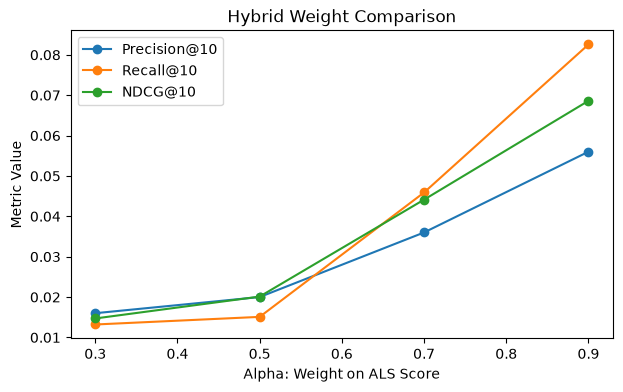

In [40]:
plt.figure(figsize=(7,4))
plt.plot(weight_results["alpha"], weight_results["precision_at_10"], marker="o", label="Precision@10")
plt.plot(weight_results["alpha"], weight_results["recall_at_10"], marker="o", label="Recall@10")
plt.plot(weight_results["alpha"], weight_results["ndcg_at_10"], marker="o", label="NDCG@10")
plt.title("Hybrid Weight Comparison")
plt.xlabel("Alpha: Weight on ALS Score")
plt.ylabel("Metric Value")
plt.legend()
plt.show()


In [42]:
eval_df = evaluate_hybrid_sample(
    alpha=FINAL_ALPHA,
    k=10,
    max_users=50
)

## Example Final Recommendations

To demonstrate the final hybrid recommender, I selected User 3874 and first examined the movies they rated highly.

- This user has a strong preference for science fiction, action, adventure, horror, and classic films like  Spaceballs, The Thing and Indiana Jones and the Last Crusade.
- Then, I generated the top 10 recommendations using the final hybrid recommender with α = 0.9. 
    - The output included the ALS predicted rating, the text-based similarity score, the poster similarity score (when available), the combined multimodal content score, and the final hybrid score used to rank each movie.
- The recommendations combine collaborative filtering with both textual and visual content information.
    - For example, movies such as Star Wars: Episode IV – A New Hope, The Exorcist, Pulp Fiction, and The Apple received poster similarity scores because poster embeddings were available, allowing visual characteristics to contribute to the final recommendation.
        - Star Wars: Episode IV – A New Hope appears both in the user's highly rated movies and in the Top-10 recommendations. 
        - Since recommendations were generated using only the training data, this proves that the hybrid recommender successfully identified one of the user's held-out preferences while also incorporating poster-based similarity into the final ranking.
    - Other recommendations, like Dr. Strangelove, Ulysses, and Seven Samurai, relied on text-based similarity because no poster embedding was available - this showed the model's ability to fall back gracefully when visual features are unavailable.
- The consistently high ALS prediction scores indicate that users with similar rating histories also rated these movies highly, while the multimodal content score helps prioritize movies that share similar themes, genres, and visual style with the user's previously liked movies.

Overall, this example demonstrates how the final hybrid recommender combines collaborative filtering, textual movie metadata, and visual poster embeddings to produce personalized recommendations while remaining robust when poster information is unavailable.

In [48]:
example_user = 3874
print("Movies rated highly by user", example_user)
ratings[(ratings["userId"] == example_user) & (ratings["rating"] >= 4)]     .merge(movies, on="movieId")[["title", "genres", "rating"]]     .head(15)

Movies rated highly by user 3874


,title,genres,rating
0,Terminator 2: Judgment Day (1991),Action|Sci-Fi|Thriller,4
1,Spaceballs (1987),Comedy|Sci-Fi,5
2,Indiana Jones and the Last Crusade (1989),Action|Adventure,5
3,2001: A Space Odyssey (1968),Drama|Mystery|Sci-Fi|Thriller,5
4,"Longest Day, The (1962)",Action|Drama|War,5
5,"Thing, The (1982)",Action|Horror|Sci-Fi|Thriller,5
6,"Fly, The (1986)",Horror|Sci-Fi,5
7,Gattaca (1997),Drama|Sci-Fi|Thriller,5
8,"Fly II, The (1989)",Horror|Sci-Fi,5
9,Bean (1997),Comedy,5


In [49]:
recommend_hybrid_for_user(user_id=example_user, top_n=10, alpha=FINAL_ALPHA)

,movieId,title,genres,prediction,text_score,poster_score,combined_content_score,hybrid_score,has_poster
0,3172,Ulysses (Ulisse) (1954),Adventure,4.807281,0.265404,NaN,0.344817,0.919141,False
1,750,Dr. Strangelove or: How I Learned to Stop Worr...,Sci-Fi|War,4.597355,0.531485,NaN,0.697930,0.918371,False
2,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Fantasy|Sci-Fi,4.679244,0.283900,0.732036,0.481703,0.908764,True
3,1997,"Exorcist, The (1973)",Horror,4.791613,0.093676,0.724318,0.275011,0.906944,True
4,2905,Sanjuro (1962),Action|Adventure,4.585357,0.466205,NaN,0.611297,0.904842,False
5,296,Pulp Fiction (1994),Crime|Drama,4.730218,0.092711,0.728334,0.274978,0.893678,True
6,2503,"Apple, The (Sib) (1998)",Drama,4.750384,0.057924,0.610227,0.207926,0.889569,True
7,2019,Seven Samurai (The Magnificent Seven) (Shichin...,Action|Drama,4.539517,0.394721,NaN,0.516433,0.882965,False
8,599,"Wild Bunch, The (1969)",Western,4.719649,0.038077,0.668449,0.201158,0.882076,True
9,1208,Apocalypse Now (1979),Drama|War,4.696774,0.080501,0.636580,0.238834,0.881891,True


## Discussion and Conclusion 

In this project, I developed a scalable hybrid movie recommender using the MovieLens 1M dataset by combining Spark ALS collaborative filtering with a multimodal content-based recommender. The content model represented movies using genres, TMDb metadata, and visual poster embeddings extracted with a pre-trained ResNet50 model, allowing recommendations to incorporate both textual and visual information.

The ALS collaborative filtering model achieved an RMSE of 0.8714, demonstrating that it successfully learned meaningful latent relationships between users and movies from more than one million ratings. The content-based component complemented ALS by capturing similarities through movie genres, plot overviews, and other metadata, while the ResNet50 poster embeddings introduced an additional visual signal whenever poster images were available. For movies without poster embeddings, the recommender automatically fell back to the text-based similarity score.

The final hybrid recommender combined normalized ALS predictions with the multimodal content similarity score. After evaluating several weighting configurations, α = 0.9 produced the strongest overall performance, achieving the highest Precision@10, Recall@10, and NDCG@10 while also improving Novelty@10 and Diversity@10. Although this configuration resulted in slightly lower catalog coverage, it demonstrated that placing greater emphasis on collaborative filtering produced more relevant recommendations without eliminating the contribution of content and visual features.

Beyond traditional ranking metrics, I also evaluated the recommender using novelty, diversity, and catalog coverage. The results showed that the recommender consistently suggested movies beyond only the most popular titles while maintaining a reasonable level of genre diversity. Catalog coverage remained relatively low, indicating that the recommender concentrated on recommending a smaller subset of highly relevant movies rather than distributing recommendations broadly across the entire catalog.

Overall, this project demonstrates how collaborative filtering, multimodal content features, and deep learning-based visual embeddings can be integrated into a scalable hybrid recommender system. It also highlights that evaluating recommender systems requires more than prediction accuracy alone. Considering ranking quality together with novelty, diversity, and catalog coverage provides a more complete understanding of recommendation performance and the trade-offs involved in building practical recommender systems.


## Limitations and Future Improvements

Limitations:

- Although MovieLens 1M is substantially larger than the datasets used in previous projects, it is still much smaller than the datasets used by commercial recommendation systems.
- Approximately 69.1% of MovieLens movies were successfully matched with TMDb metadata. Movies that could not be matched relied only on their MovieLens genres and did not benefit from the additional metadata or poster-based features.
- Poster embeddings were only available for matched movies, so the visual component of the recommender could not be applied across the entire catalog. 
    - In these cases, the hybrid model automatically fell back to text-based similarity.
- The recommender produced relatively low catalog coverage, reflecting its tendency to prioritize recommending the most relevant movies rather than exposing a wider portion of the catalog.

Future improvements:

- Incorporate richer TMDb features such as actors, directors, production companies, keywords, and user-generated tags to improve the content representation of movies.
- Replace the fixed hybrid weighting strategy with a dynamic approach that adjusts the balance between collaborative filtering, textual similarity, and visual similarity based on the amount of user history or the availability of metadata.
- Deploy the recommender as an interactive web application to collect real user feedback and compare offline evaluation metrics with online user engagement.


In [ ]:
spark.stop()
